# Métricas de evaluación

Entrena un modelo regularizado reproducible, selecciona pesos con el conjunto de desarrollo y calcula métricas finales una sola vez sobre test.


# Preparación de datos MNIST

In [6]:
# Librerías, semilla y carga de MNIST
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)

(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train, x_dev, y_train, y_dev = train_test_split(
    x_train_full, y_train_full, test_size=0.20, random_state=SEED, stratify=y_train_full
)
x_train = x_train.astype("float32") / 255.0
x_dev = x_dev.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
print("Train:", x_train.shape, "Dev:", x_dev.shape, "Test:", x_test.shape)


TensorFlow: 2.21.0
Train: (48000, 28, 28) Dev: (12000, 28, 28) Test: (10000, 28, 28)


## Entrenamiento del modelo evaluado

El conjunto de prueba se reserva para la evaluación final.

In [7]:
def crear_modelo_regularizado():
    modelo = keras.Sequential([
        layers.Input(shape=(28, 28)), layers.Flatten(),
        layers.Dense(512, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.30),
        layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.30),
        layers.Dense(10, activation="softmax")])
    modelo.compile(optimizer=keras.optimizers.Adam(0.001),
        loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return modelo

modelo_eval = crear_modelo_regularizado()
hist_eval = modelo_eval.fit(x_train, y_train, validation_data=(x_dev, y_dev),
    epochs=20, batch_size=64, callbacks=[callbacks.EarlyStopping(
        monitor="val_loss", patience=2, restore_best_weights=True)], verbose=1)
print("Épocas ejecutadas:", len(hist_eval.history["loss"]))


Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9116 - loss: 0.3675 - val_accuracy: 0.9610 - val_loss: 0.2114
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9590 - loss: 0.2138 - val_accuracy: 0.9663 - val_loss: 0.1957
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9666 - loss: 0.1895 - val_accuracy: 0.9711 - val_loss: 0.1800
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9720 - loss: 0.1728 - val_accuracy: 0.9725 - val_loss: 0.1759
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9743 - loss: 0.1644 - val_accuracy: 0.9726 - val_loss: 0.1768
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9754 - loss: 0.1582 - val_accuracy: 0.9762 - val_loss: 0.1675
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9789 - loss: 0.1517 - val_accuracy: 0.9745 - val_loss: 0.1722
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9791 - loss: 0.1506 - val_accuracy: 

In [8]:
loss_test, accuracy_test = modelo_eval.evaluate(x_test, y_test, verbose=0)
probabilidades_test = modelo_eval.predict(x_test, verbose=0)
y_pred = np.argmax(probabilidades_test, axis=1)
precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)

# TABLA RESUMEN DE MÉTRICAS
Se organizan las métricas calculadas en un DataFrame.
Esto facilita presentar y comparar los principales indicadores del modelo.


In [9]:
metricas = pd.DataFrame({"metrica": ["Loss", "Accuracy", "Precision macro", "Recall macro", "F1 macro"],
    "resultado": [loss_test, accuracy_test, precision_macro, recall_macro, f1_macro]})
display(metricas)

,metrica,resultado
0,Loss,0.158200
1,Accuracy,0.978300
2,Precision macro,0.978169
3,Recall macro,0.978063
4,F1 macro,0.978108


# INFORME DETALLADO DE CLASIFICACIÓN
classification_report presenta precision, recall y F1 para cada dígito.
También muestra promedios y soporte de cada clase.

digits=4 establece cuatro decimales en el resultado.


In [10]:
print(classification_report(y_test, y_pred, digits=4, zero_division=0))


              precision    recall  f1-score   support

           0     0.9887    0.9857    0.9872       980
           1     0.9860    0.9947    0.9904      1135
           2     0.9824    0.9758    0.9791      1032
           3     0.9763    0.9792    0.9778      1010
           4     0.9806    0.9766    0.9786       982
           5     0.9775    0.9753    0.9764       892
           6     0.9710    0.9770    0.9740       958
           7     0.9794    0.9708    0.9751      1028
           8     0.9712    0.9702    0.9707       974
           9     0.9685    0.9752    0.9719      1009

    accuracy                         0.9783     10000
   macro avg     0.9782    0.9781    0.9781     10000
weighted avg     0.9783    0.9783    0.9783     10000



# MATRIZ DE CONFUSIÓN
La matriz indica cuántas veces cada clase real fue predicha como cada clase.
Las filas representan las clases reales y las columnas las clases predichas.
La diagonal principal contiene los aciertos; los valores fuera de ella son errores.

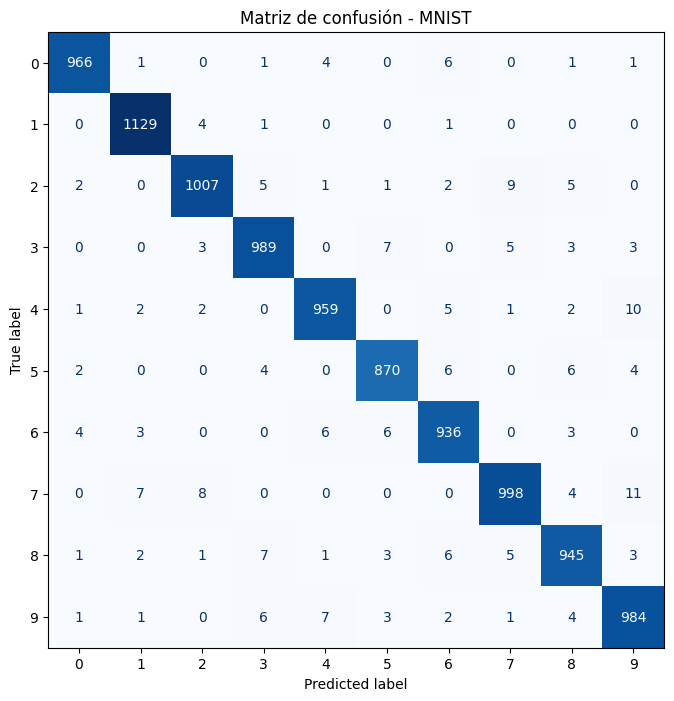

In [11]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10)).plot(
    ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de confusión - MNIST")
plt.show()


# IDENTIFICACIÓN DE LA CONFUSIÓN MÁS FRECUENTE
Se copia la matriz para no modificar la original.
Se pone la diagonal en cero para ignorar los aciertos.
np.argmax encuentra el par de clases con mayor número de errores.
Se informa qué dígito real fue confundido con qué predicción y cuántas veces ocurrió.


In [12]:
cm_errores = cm.copy()
np.fill_diagonal(cm_errores, 0)
real_confundido, predicho_como = np.unravel_index(np.argmax(cm_errores), cm_errores.shape)
cantidad = cm_errores[real_confundido, predicho_como]
print(f"Confusión más frecuente: {real_confundido} como {predicho_como} ({cantidad} veces)")

Confusión más frecuente: 7 como 9 (11 veces)


# VISUALIZACIÓN DE UN EJEMPLO DE ERROR
Se localiza la primera imagen que corresponde a la confusión más frecuente.
Si existe al menos un ejemplo, se muestra la imagen en escala de grises.
El título permite comparar la etiqueta real con la predicción del modelo.


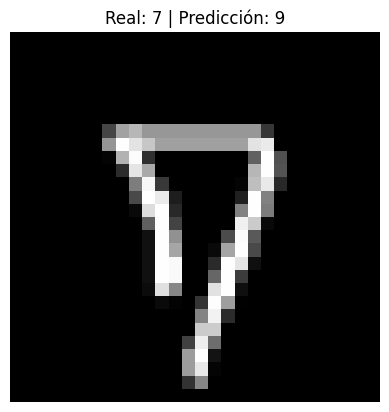

In [13]:
indices = np.where((y_test == real_confundido) & (y_pred == predicho_como))[0]
if len(indices):
    idx = indices[0]
    plt.imshow(x_test[idx], cmap="gray")
    plt.title(f"Real: {y_test[idx]} | Predicción: {y_pred[idx]}")
    plt.axis("off"); plt.show()
